In [3]:
# Import necessary libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Sklearn library
from sklearn.model_selection import train_test_split

# TensorFlow and Keras libraries
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.datasets import imdb
from tensorflow.keras.callbacks import EarlyStopping

In [4]:
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=10000)

In [5]:
data = np.concatenate((X_train, X_test), axis=0)
label = np.concatenate((y_train, y_test), axis=0)

In [6]:
print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)


X_train shape: (25000,)
X_test shape : (25000,)
y_train shape: (25000,)
y_test shape : (25000,)


In [7]:
print("Sample Review:", X_train[0])
print("Sample Label :", y_train[0])

Sample Review: [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 5345, 19, 178, 32]
Sample Label : 1


In [8]:
index = imdb.get_word_index()
reverse_index = dict((value, key) for (key, value) in index.items())

In [9]:
decoded_review = " ".join([reverse_index.get(i-3, "#") for i in data[0]])
print(decoded_review)

# this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert # is an amazing actor and now the same being director # father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for # and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also # to the two little boy's that played the # of norman and paul they were just brilliant children are often left out of the # list i think because the stars that play them all grown up are such a big profile for the whole film but these children are amazing and should be praised for what they have done don't you thi

In [10]:
def vectorize(sequences, dimension=10000):
    # Specify dtype='float32' to save 50% RAM
    results = np.zeros((len(sequences), dimension), dtype='float32')
    for i, sequence in enumerate(sequences):
        results[i, sequence] = 1.
    return results

In [11]:
data = vectorize(data)

In [12]:
label = np.array(label).astype("float32")

In [13]:
print("Categories:", np.unique(label))

Categories: [0. 1.]


In [14]:
print("Number of unique words:",
      len(np.unique(np.hstack(X_train))))

Number of unique words: 9998


In [15]:
length = [len(i) for i in X_train]

In [16]:
print("Average Review Length:", np.mean(length))
print("Standard Deviation    :", round(np.std(length)))

Average Review Length: 238.71364
Standard Deviation    : 176


In [17]:
labelDF = pd.DataFrame({'label': label})

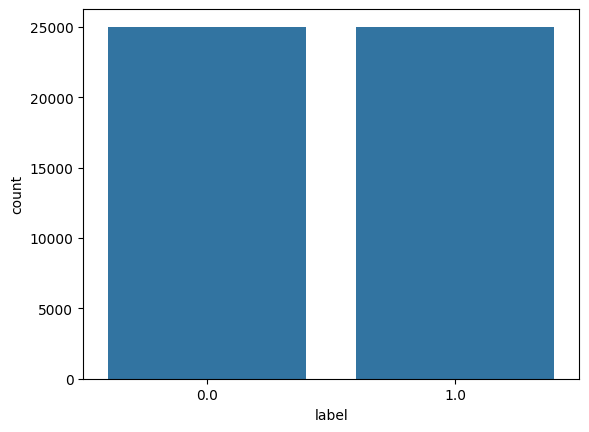

In [18]:
sns.countplot(x='label', data=labelDF)
plt.show()

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    data,
    label,
    test_size=0.20,
    random_state=1
)

In [20]:
model = Sequential([
    Dense(50, activation='relu', input_shape=(10000,)),
    Dropout(0.3),
    Dense(50, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 50)             │       500,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 502,651 (1.92 MB)

 Trainable params: 502,651 (1.92 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
callback = EarlyStopping(
    monitor='val_loss',
    patience=3
)

In [22]:
results = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=500,
    validation_data=(X_test, y_test),
    callbacks=[callback],
    verbose=1
)

Epoch 1/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 6s 57ms/step - accuracy: 0.8131 - loss: 0.4199 - val_accuracy: 0.8869 - val_loss: 0.2742
Epoch 2/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - accuracy: 0.9137 - loss: 0.2253 - val_accuracy: 0.8958 - val_loss: 0.2534
Epoch 3/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - accuracy: 0.9378 - loss: 0.1688 - val_accuracy: 0.8960 - val_loss: 0.2699
Epoch 4/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - accuracy: 0.9537 - loss: 0.1285 - val_accuracy: 0.8909 - val_loss: 0.2978
Epoch 5/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - accuracy: 0.9681 - loss: 0.0956 - val_accuracy: 0.8896 - val_loss: 0.3443


In [23]:
score = model.evaluate(X_test, y_test, batch_size=500)
print("\nTest Loss     :", score[0])
print("Test Accuracy :", score[1])

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.8896 - loss: 0.3443

Test Loss     : 0.34427759051322937
Test Accuracy : 0.8895999789237976


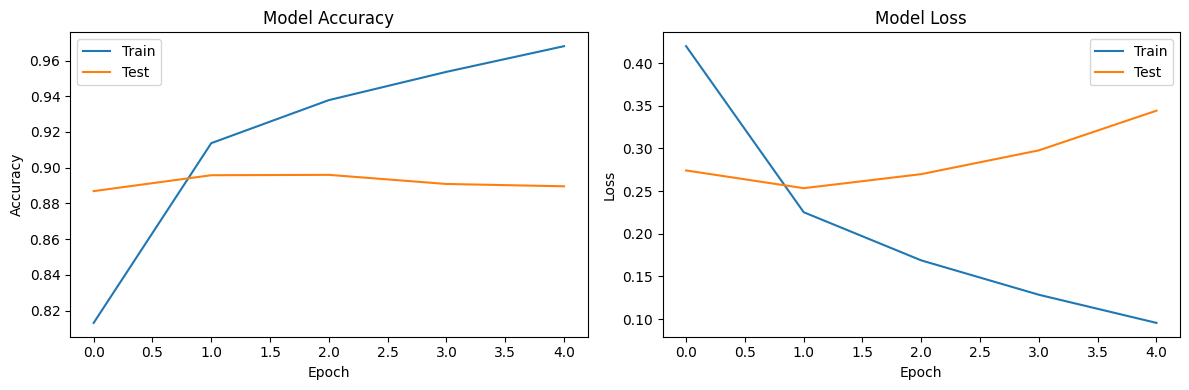

In [24]:
# Accuracy Plot
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(results.history['accuracy'], label='Train')
plt.plot(results.history['val_accuracy'], label='Test')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(results.history['loss'], label='Train')
plt.plot(results.history['val_loss'], label='Test')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()

plt.tight_layout()
plt.show()